In [7]:

import joblib
from sklearn.preprocessing import LabelEncoder
from ovo_svm import OvO_SVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt




In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
x = joblib.load("./features/x_features_hog.joblib")
y = joblib.load("./features/y_labels_hog.joblib")

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [11]:
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")

In [ ]:
# model = OvO_SVM()
# model.fit(train_x, train_y, save_path="./models/from_scratch_SVM")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18729337543660987s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  62 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0478360652923584s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  88 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04821944236755371s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:    0.3s
[Parallel(n_jobs

[ALL DONE]


In [13]:
model = OvO_SVM.load("./models/from_scratch_SVM")

In [ ]:
# meta = joblib.load("./OvO_SVM/meta.joblib")
# meta["classes"] = {}

In [14]:
predictions = model.predict(test_x)

In [16]:
F1 = f1_score(test_y, predictions, average='weighted')
precision = precision_score(test_y, predictions, average='weighted')
recall = recall_score(test_y, predictions, average='weighted')
accuracy = accuracy_score(test_y, predictions)

print("F1 Score:", F1)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

F1 Score: 0.8663082315905903
Precision: 0.8706778336239219
Recall: 0.8643543138344313
Accuracy: 0.8643543138344313


In [17]:
conf_matrix = confusion_matrix(test_y, predictions)

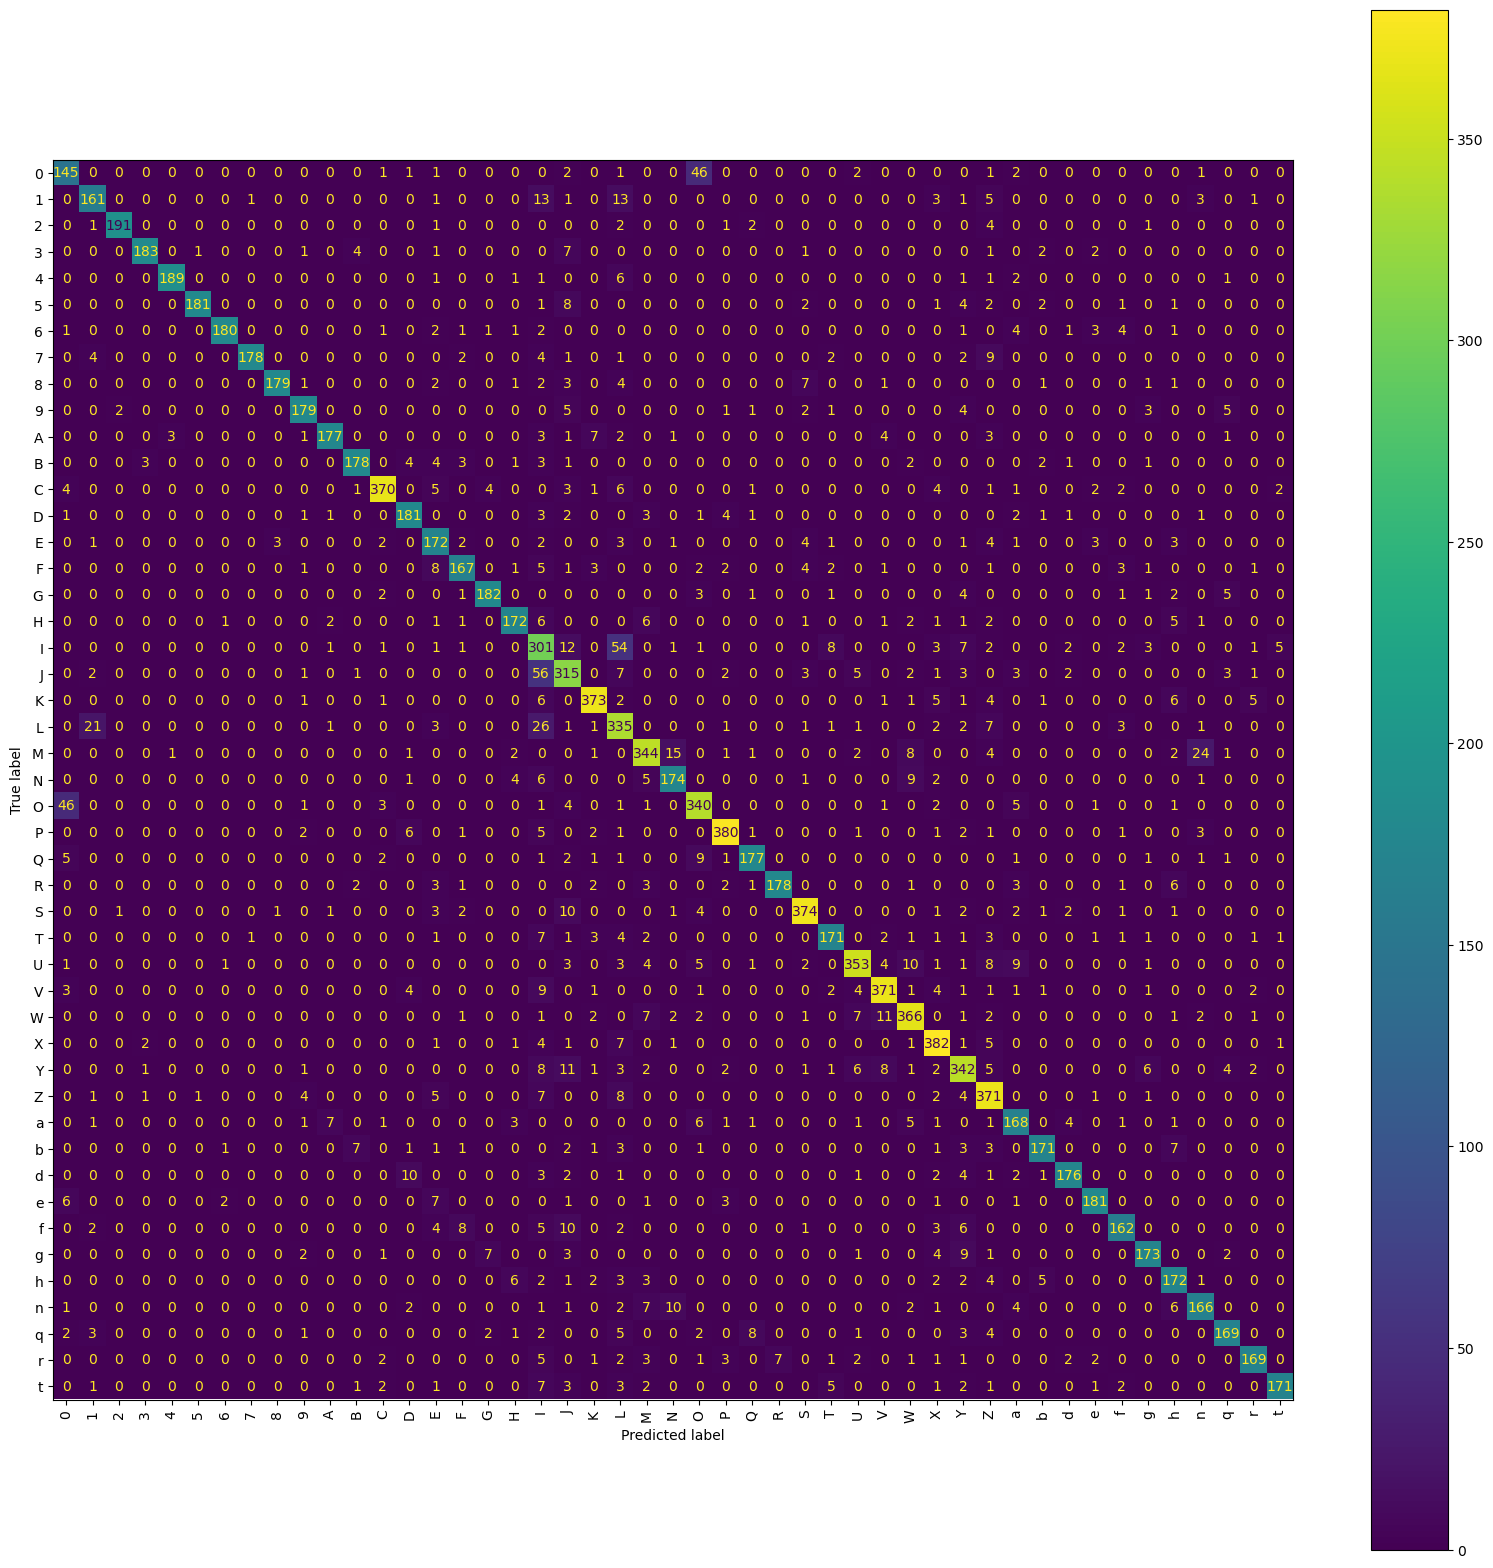

In [18]:
fig, ax = plt.subplots(figsize=(20, 20))

ConfusionMatrixDisplay.from_predictions(
    test_y,
    predictions,
    xticks_rotation='vertical',
    display_labels=le.classes_,
    ax=ax
)

plt.show()